In [1]:
cd ../..

/home/sangonvi/Cefet/repositories/rionowcastdf


In [2]:
# =============================================================================
# Notebook 04
# Temporal Climatology
# =============================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.style.use("ggplot")

DATASET = Path("datasets/radar_statistics/summary.parquet")
FIGURES = Path("figures/notebook04")

FIGURES.mkdir(
    parents=True,
    exist_ok=True
)

df = pd.read_parquet(DATASET)

df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df.head())

            timestamp  rain_pixels  rain_fraction       mean       std  \
0 2011-01-17 15:36:00          184       0.031293  31.663322  8.129971   
1 2011-01-17 15:44:00          207       0.035204  29.805325  7.576298   
2 2011-01-17 15:46:00          213       0.036224  29.541319  7.312479   
3 2011-01-17 15:48:00          197       0.033503  29.265385  7.915115   
4 2011-01-17 15:50:00          192       0.032653  29.176849  7.859232   

   maximum       volume        p50   p90        p95   p99  
0     45.0  5826.051270  30.000000  40.0  45.000000  45.0  
1     45.0  6169.702148  30.000000  40.0  43.898239  45.0  
2     45.0  6292.300781  30.000000  40.0  45.000000  45.0  
3     45.0  5765.280762  30.000000  40.0  44.441284  45.0  
4     45.0  5601.955078  28.380985  40.0  43.221180  45.0  


In [3]:
# =============================================================================
# Month
# =============================================================================

df["month"] = df.timestamp.dt.month

monthly = df.groupby("month").agg(
    rainfall=("volume","mean"),
    maximum=("maximum","mean"),
    rain_fraction=("rain_fraction","mean")
)

monthly

,rainfall,maximum,rain_fraction
month,,,
1,3157.585953,24.627186,0.020414
2,3681.451899,22.268710,0.021633
3,2055.605796,22.407902,0.013550
4,1055.046416,17.768021,0.007142
5,1738.709741,13.712893,0.008893
6,762.039021,12.816343,0.004926
7,601.119199,11.202380,0.003856
8,1512.737403,13.163253,0.008197
9,2641.582370,15.380681,0.013966


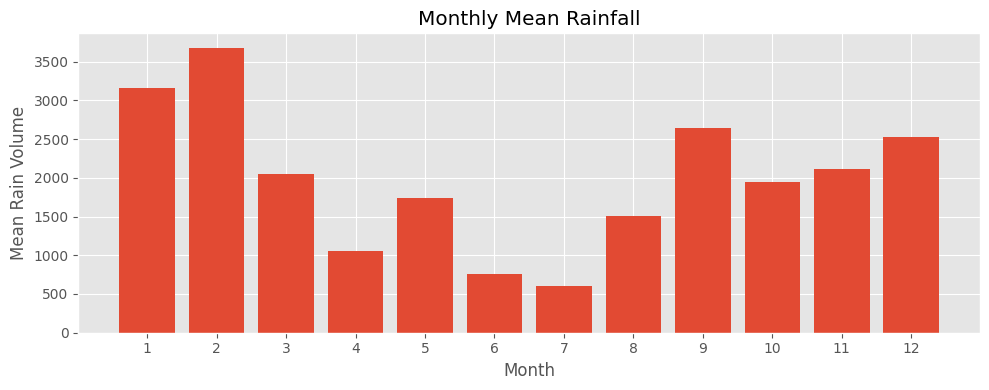

In [4]:
plt.figure(figsize=(10,4))

plt.bar(
    monthly.index,
    monthly.rainfall
)

plt.xticks(range(1,13))

plt.xlabel("Month")

plt.ylabel("Mean Rain Volume")

plt.title("Monthly Mean Rainfall")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure01_monthly_volume.png",
    dpi=300
)

plt.show()

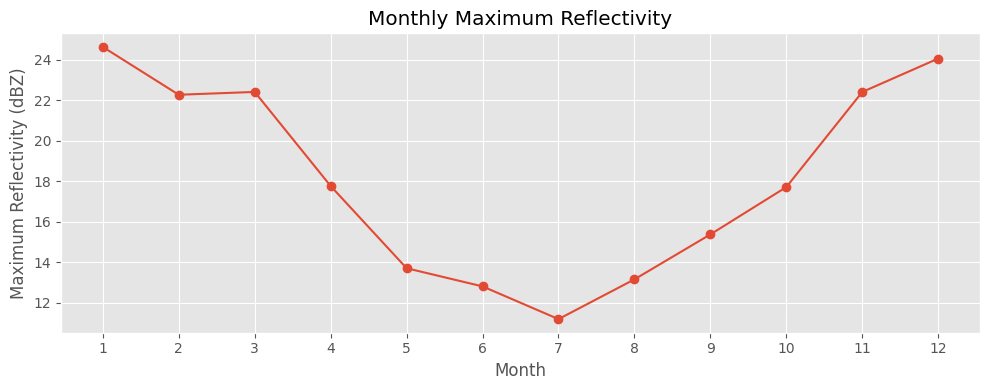

In [5]:
plt.figure(figsize=(10,4))

plt.plot(
    monthly.index,
    monthly.maximum,
    marker="o"
)

plt.xticks(range(1,13))

plt.xlabel("Month")

plt.ylabel("Maximum Reflectivity (dBZ)")

plt.title("Monthly Maximum Reflectivity")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure02_monthly_maximum.png",
    dpi=300
)

plt.show()

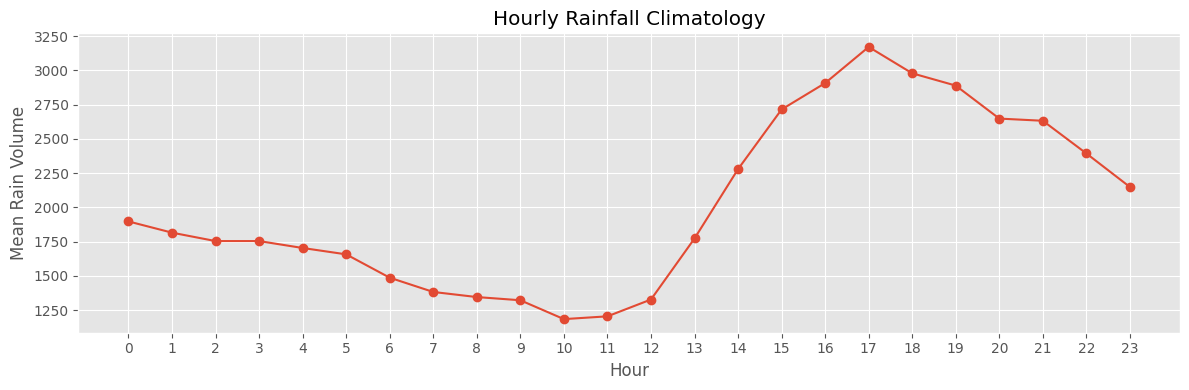

In [6]:
# =============================================================================
# Hour
# =============================================================================

df["hour"] = df.timestamp.dt.hour

hourly = df.groupby("hour").agg(
    rainfall=("volume","mean"),
    maximum=("maximum","mean"),
    rain_fraction=("rain_fraction","mean")
)

hourly

plt.figure(figsize=(12,4))

plt.plot(
    hourly.index,
    hourly.rainfall,
    marker="o"
)

plt.xticks(range(24))

plt.xlabel("Hour")

plt.ylabel("Mean Rain Volume")

plt.title("Hourly Rainfall Climatology")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure03_hourly_volume.png",
    dpi=300
)

plt.show()

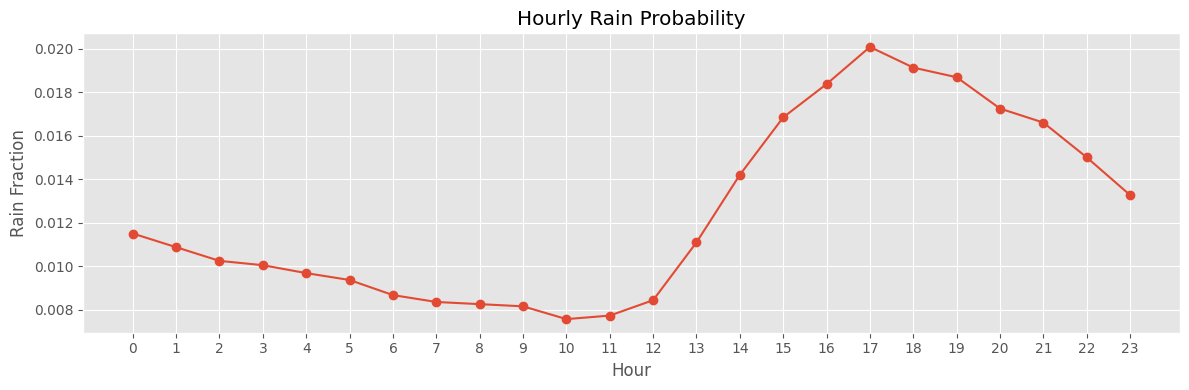

In [7]:
plt.figure(figsize=(12,4))

plt.plot(
    hourly.index,
    hourly.rain_fraction,
    marker="o"
)

plt.xticks(range(24))

plt.xlabel("Hour")

plt.ylabel("Rain Fraction")

plt.title("Hourly Rain Probability")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure04_hourly_probability.png",
    dpi=300
)

plt.show()

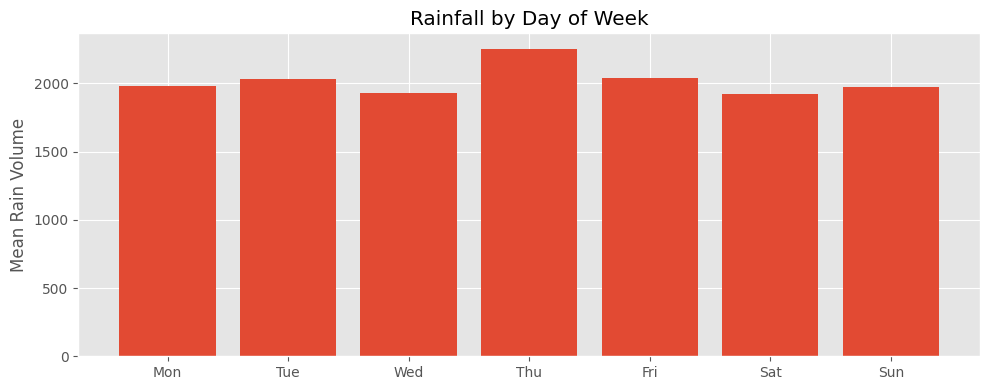

In [8]:
# =============================================================================
# Day of week
# =============================================================================

df["weekday"] = df.timestamp.dt.dayofweek

weekday = df.groupby("weekday").agg(
    rainfall=("volume","mean"),
    maximum=("maximum","mean"),
    rain_fraction=("rain_fraction","mean")
)

weekday
labels = [
    "Mon",
    "Tue",
    "Wed",
    "Thu",
    "Fri",
    "Sat",
    "Sun"
]

plt.figure(figsize=(10,4))

plt.bar(
    labels,
    weekday.rainfall
)

plt.ylabel("Mean Rain Volume")

plt.title("Rainfall by Day of Week")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure05_weekday.png",
    dpi=300
)

plt.show()

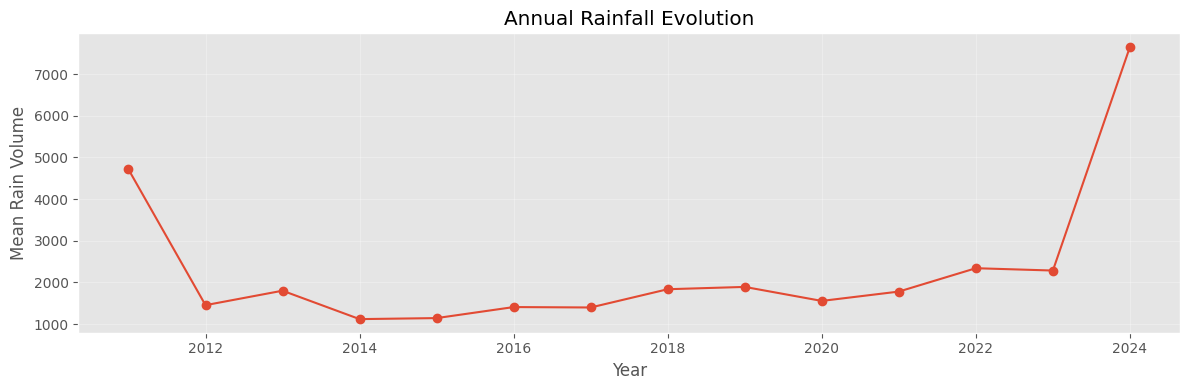

In [9]:
# =============================================================================
# Year
# =============================================================================

df["year"] = df.timestamp.dt.year

annual = df.groupby("year").agg(
    rainfall=("volume","mean"),
    maximum=("maximum","mean"),
    rain_fraction=("rain_fraction","mean")
)

annual

plt.figure(figsize=(12,4))

plt.plot(
    annual.index,
    annual.rainfall,
    marker="o"
)

plt.xlabel("Year")

plt.ylabel("Mean Rain Volume")

plt.title("Annual Rainfall Evolution")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure06_annual_volume.png",
    dpi=300
)

plt.show()

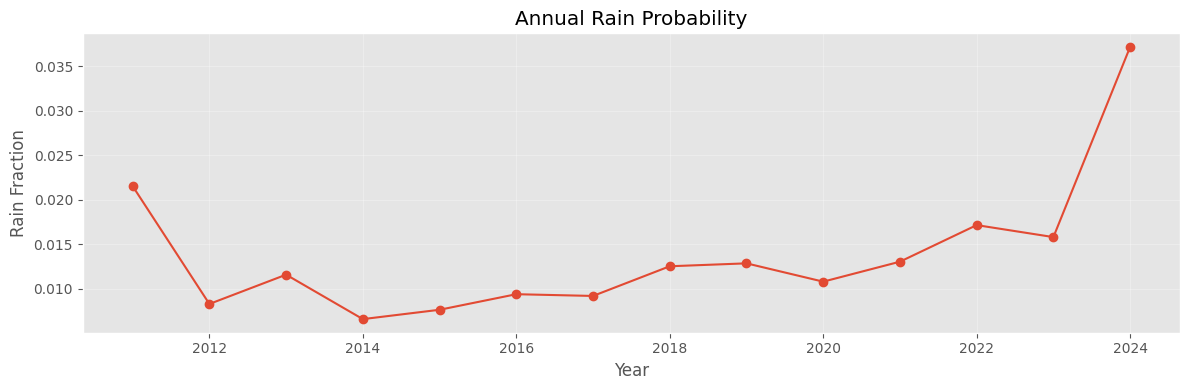

In [10]:
plt.figure(figsize=(12,4))

plt.plot(
    annual.index,
    annual.rain_fraction,
    marker="o"
)

plt.xlabel("Year")

plt.ylabel("Rain Fraction")

plt.title("Annual Rain Probability")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES/"figure07_annual_probability.png",
    dpi=300
)

plt.show()

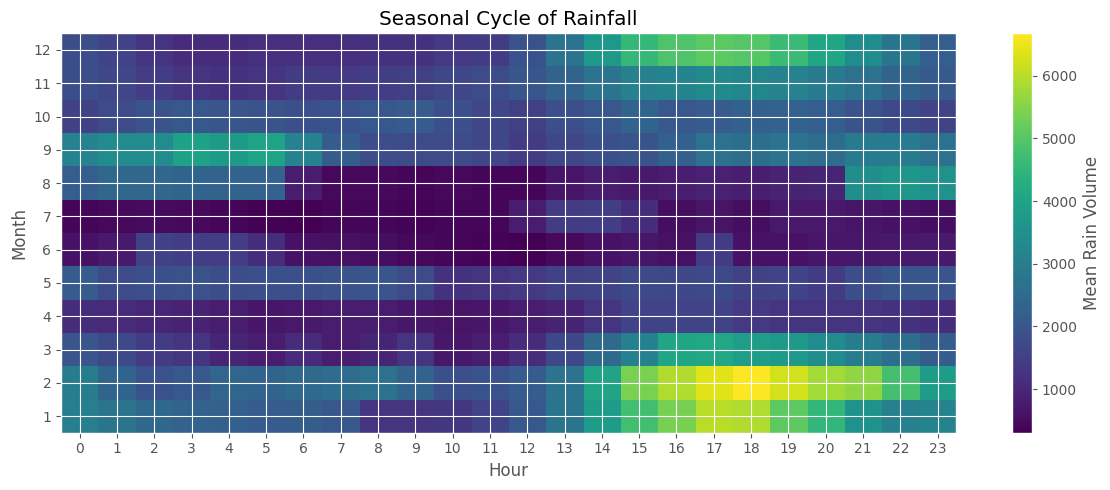

In [11]:
pivot = df.pivot_table(
    values="volume",
    index=df.timestamp.dt.month,
    columns=df.timestamp.dt.hour,
    aggfunc="mean"
)

plt.figure(figsize=(12,5))

plt.imshow(
    pivot,
    aspect="auto",
    origin="lower"
)

plt.colorbar(
    label="Mean Rain Volume"
)

plt.xticks(
    range(24),
    range(24)
)

plt.yticks(
    range(12),
    range(1,13)
)

plt.xlabel("Hour")

plt.ylabel("Month")

plt.title("Seasonal Cycle of Rainfall")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure08_month_hour_heatmap.png",
    dpi=300
)

plt.show()